## **TP Especial: Transferencia de blancos terapéuticos potenciales a patógenos bacterianos críticos de la OMS mediante análisis filogenético y estructural comparativo**

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from Bio.Seq import Seq
from Bio import Entrez, SeqIO
import time
import os

### **Paso 3: Obtención de secuencias -> NCBI/GenBank, BioPython (Entrez)**

In [2]:
#Configuración 
Entrez.email = "tu_email@gmail.com"
OUTPUT_DIR = "sequences_16S"
os.makedirs(OUTPUT_DIR, exist_ok=True)

#Lista de organismos
organismos = [
    ("Achromobacter insuavis AXX-A",            "Achromobacter insuavis"),
    ("Achromobacter xylosoxidans",               "Achromobacter xylosoxidans"),
    ("Bartonella bacilliformis",                 "Bartonella bacilliformis"),
    ("Helicobacter pylori 26695",                "Helicobacter pylori 26695"),
    ("Helicobacter pylori India7",               "Helicobacter pylori India7"),
    ("Klebsiella pneumoniae Kp13",               "Klebsiella pneumoniae"),
    ("Listeria monocytogenes EGD-e",             "Listeria monocytogenes EGD-e"),
    ("Mycobacterium leprae Br4923",              "Mycobacterium leprae"),
    ("Mycobacterium tuberculosis H37Rv",         "Mycobacterium tuberculosis H37Rv"),
    ("Mycoplasma bovis PG45",                    "Mycoplasma bovis"),
    ("Mycoplasma gallisepticum R(low)",          "Mycoplasma gallisepticum"),
    ("Mycoplasma hominis ATCC 23114",            "Mycoplasma hominis"),
    ("Pseudomonas extremaustralis 14-3b",        "Pseudomonas extremaustralis"),
    ("Shigella dysenteriae Sd197",               "Shigella dysenteriae"),
    ("Staphylococcus aureus",                    "Staphylococcus aureus"),
    ("Staphylococcus aureus N315",               "Staphylococcus aureus N315"),
    ("Wolbachia endosymbiont Brugia malayi",     "Wolbachia endosymbiont of Brugia malayi"),
    ("Xanthomonas translucens undulosa",         "Xanthomonas translucens"),
    ("Acinetobacter baumannii",                  "Acinetobacter baumannii"),
    ("Escherichia coli",                         "Escherichia coli"),
    ("Enterobacter cloacae",                     "Enterobacter cloacae"),
    ("Proteus mirabilis",                        "Proteus mirabilis"),
    ("Serratia marcescens",                      "Serratia marcescens"),
    ("Citrobacter freundii",                     "Citrobacter freundii"),
    ("Morganella morganii",                      "Morganella morganii"),
    ("Salmonella enterica Typhi",                "Salmonella enterica Typhi"),
    ("Salmonella enterica",                      "Salmonella enterica"),
    ("Enterococcus faecium",                     "Enterococcus faecium"),
    ("Neisseria gonorrhoeae",                    "Neisseria gonorrhoeae"),
]

#Función de descarga
#Busca la secuencia 16S rRNA de un organismo en NCBI y la guarda como FASTA. Retorna True si tuvo éxito, False si no encontró nada.
def descargar_16S(nombre_display, nombre_busqueda, output_dir):
    
    filename = os.path.join(output_dir, f"{nombre_display.replace(' ', '_')}.fasta")
    
    # Si ya está descargado, saltear
    if os.path.exists(filename):
        print(f"  [SKIP] {nombre_display} — ya descargado")
        return True

    query = f'"{nombre_busqueda}"[Organism] AND 16S ribosomal RNA[Title] AND 1000:2000[SLEN]'
    
    try:
        # Buscar en nucleótidos
        handle = Entrez.esearch(db="nucleotide", term=query, retmax=5)
        record = Entrez.read(handle)
        handle.close()
        
        if not record["IdList"]:
            # Intentar búsqueda más amplia si no encontró nada
            query2 = f'"{nombre_busqueda}"[Organism] AND 16S[Title]'
            handle = Entrez.esearch(db="nucleotide", term=query2, retmax=5)
            record = Entrez.read(handle)
            handle.close()
        
        if not record["IdList"]:
            print(f"  [ERROR] {nombre_display} — no se encontró secuencia 16S")
            return False
        
        # Descargar el primer resultado
        seq_id = record["IdList"][0]
        handle = Entrez.efetch(db="nucleotide", id=seq_id, rettype="fasta", retmode="text")
        seq_data = handle.read()
        handle.close()
        
        # Reemplazar el header de NCBI por el nombre del organismo
        lineas = seq_data.strip().split("\n")
        nuevo_header = f">{nombre_display}"
        seq_limpia = nuevo_header + "\n" + "\n".join(lineas[1:]) + "\n"
        
        with open(filename, "w") as f:
            f.write(seq_limpia)
        
        print(f"  [OK]    {nombre_display} — descargado (ID: {seq_id})")
        return True

    except Exception as e:
        print(f"  [ERROR] {nombre_display} — {str(e)}")
        return False

#Descarga principal
print("=== Descargando secuencias 16S rRNA ===\n")
exitosos = []
fallidos = []

for nombre_display, nombre_busqueda in organismos:
    resultado = descargar_16S(nombre_display, nombre_busqueda, OUTPUT_DIR)
    if resultado:
        exitosos.append(nombre_display)
    else:
        fallidos.append(nombre_display)
    time.sleep(0.4)  # respetar límite de NCBI (max 3 requests/seg sin API key)

print(f"\n=== Resultado ===")
print(f"Exitosos: {len(exitosos)}/{len(organismos)}")
if fallidos:
    print(f"Fallidos: {fallidos}")

#Concatenar todo en un único FASTA
output_file = "all_16S.fasta"
count = 0
with open(output_file, "w") as out:
    for nombre_display, _ in organismos:
        filename = os.path.join(OUTPUT_DIR, f"{nombre_display.replace(' ', '_')}.fasta")
        if os.path.exists(filename):
            with open(filename, "r") as f:
                out.write(f.read())
            count += 1

print(f"\nArchivo final: {output_file} ({count} secuencias)")

=== Descargando secuencias 16S rRNA ===

  [OK]    Achromobacter insuavis AXX-A — descargado (ID: 3334208908)
  [OK]    Achromobacter xylosoxidans — descargado (ID: 3340051652)
  [OK]    Bartonella bacilliformis — descargado (ID: 645322580)
  [ERROR] Helicobacter pylori 26695 — no se encontró secuencia 16S
  [ERROR] Helicobacter pylori India7 — no se encontró secuencia 16S
  [OK]    Klebsiella pneumoniae Kp13 — descargado (ID: 3349475045)
  [OK]    Listeria monocytogenes EGD-e — descargado (ID: 2033714015)
  [OK]    Mycobacterium leprae Br4923 — descargado (ID: 44404)
  [OK]    Mycobacterium tuberculosis H37Rv — descargado (ID: 2472220576)
  [OK]    Mycoplasma bovis PG45 — descargado (ID: 1269859167)
  [OK]    Mycoplasma gallisepticum R(low) — descargado (ID: 2282373281)
  [ERROR] Mycoplasma hominis ATCC 23114 — no se encontró secuencia 16S
  [OK]    Pseudomonas extremaustralis 14-3b — descargado (ID: 3342257791)
  [OK]    Shigella dysenteriae Sd197 — descargado (ID: 3336902029)
  [OK]

In [3]:
# Resolución manual de fallidos
# Buscamos con términos más amplios

fallidos_fix = [
    ("Helicobacter pylori 26695",       "Helicobacter pylori",    "26695"),
    ("Helicobacter pylori India7",       "Helicobacter pylori",    "India7"),
    ("Mycoplasma hominis ATCC 23114",    "Mycoplasma hominis",     None),
]

for nombre_display, nombre_busqueda, cepa in fallidos_fix:
    if cepa:
        query = f'"{nombre_busqueda}"[Organism] AND 16S[Title] AND "{cepa}"[All Fields]'
    else:
        query = f'"{nombre_busqueda}"[Organism] AND 16S ribosomal RNA[Title]'
    
    handle = Entrez.esearch(db="nucleotide", term=query, retmax=5)
    record = Entrez.read(handle)
    handle.close()
    
    print(f"{nombre_display}: {record['IdList']}")
    time.sleep(0.4)

Helicobacter pylori 26695: []
Helicobacter pylori India7: []
Mycoplasma hominis ATCC 23114: []


In [1]:
from Bio import Entrez, SeqIO
import time

Entrez.email = "tu_email@gmail.com"

# Buscamos directamente en la base de genes, no en nucleotide
handle = Entrez.esearch(
    db="gene",
    term='"Helicobacter pylori 26695"[Organism] AND 16S ribosomal RNA[Gene Name]',
    retmax=5
)
record = Entrez.read(handle)
handle.close()

print(record["IdList"])

[]


### **Paso 5: Construcción del árbol filogenético -> BioPython + Neighbor-Joining y Paso 6: Visualización del árbol -> BioPython + matplotlib**

In [ ]:
#Corregir headers del FASTA alineado
input_file = "all_16S_aligned.fasta"
output_file = "all_16S_aligned_fixed.fasta"

with open(input_file, "r") as f_in, open(output_file, "w") as f_out:
    for linea in f_in:
        if linea.startswith(">"):
            # Reemplazar espacios por guiones bajos en el header
            linea = linea.replace(" ", "_")
        f_out.write(linea)

print("Headers corregidos, archivo guardado como:", output_file)

#Verificar que no hay duplicados
from collections import Counter

alignment = AlignIO.read(output_file, "fasta")
nombres = [seq.id for seq in alignment]
for i, n in enumerate(nombres):
    print(i+1, n)

duplicados = [n for n, count in Counter(nombres).items() if count > 1]
print(f"\nDuplicados: {duplicados}")

Alineamiento cargado: 24 secuencias, 1585 posiciones

Matriz de distancias calculada OK
Árbol NJ construido OK
Árbol guardado en arbol_16S.nwk


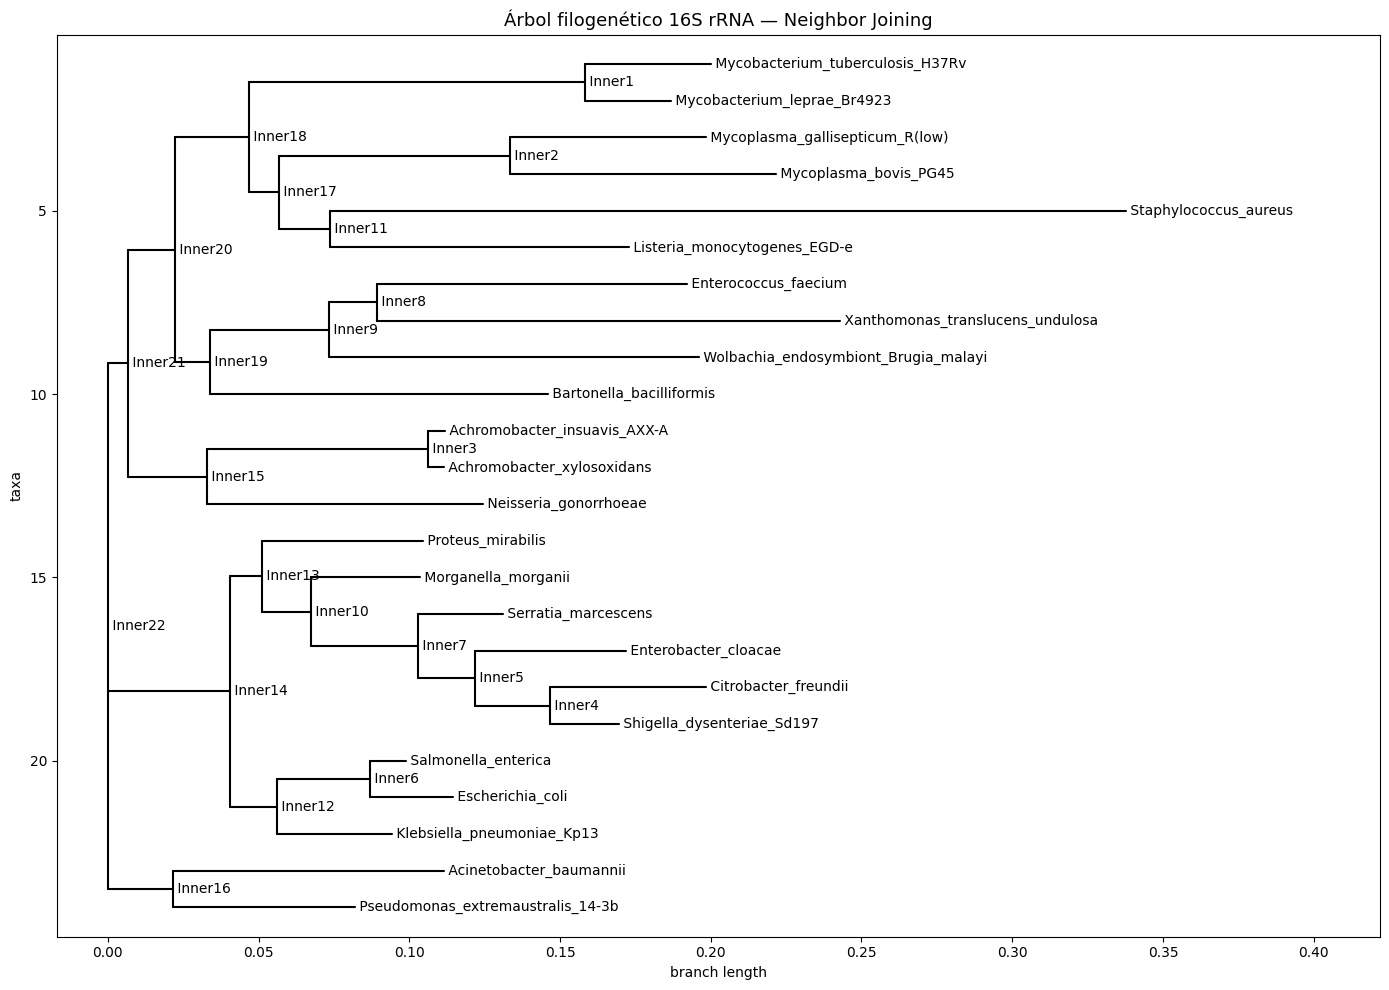

Figura guardada en arbol_16S.png


In [ ]:
from Bio import AlignIO, Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
import matplotlib.pyplot as plt

#1. Cargar el alineamiento
alignment = AlignIO.read("all_16S_aligned_fixed.fasta", "fasta")
print(f"Alineamiento cargado: {len(alignment)} secuencias, {alignment.get_alignment_length()} posiciones")

#2. Calcular matriz de distancias (modelo Jukes-Cantor)
calculator = DistanceCalculator("identity")
matriz = calculator.get_distance(alignment)
print("\nMatriz de distancias calculada OK")

#3. Construir árbol por Neighbor-Joining
constructor = DistanceTreeConstructor(calculator, method="nj")
arbol = constructor.build_tree(alignment)
print("Árbol NJ construido OK")

#4. Guardar el árbol en formato Newick
Phylo.write(arbol, "arbol_16S.nwk", "newick")
print("Árbol guardado en arbol_16S.nwk")

#5. Visualizar
fig, ax = plt.subplots(figsize=(14, 10))
Phylo.draw(arbol, axes=ax, do_show=False)
ax.set_title("Árbol filogenético 16S rRNA — Neighbor Joining", fontsize=13)
plt.tight_layout()
plt.savefig("arbol_16S.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en arbol_16S.png")

### **Paso 8: Extracción y transferencia de blancos -> Target Pathogen**

Las columnas son gene, human_offtarget, druggability y score (este último es el score de Target-Pathogen, no el nuestro). 

Todos los 39 tienen human_offtarget = 1, lo que significa que ninguno tiene homólogos humanos detectables, que es el mejor valor posible.
Dado que todos tienen human_offtarget = 1, nuestra función de score:

Score = 0.6 × human_offtarget + 0.4 × druggability

Se simplifica a:

Score = 0.6 + 0.4 × druggability

O sea el ranking va a estar determinado exclusivamente por druggability. Igual lo calculamos formalmente para documentarlo bien.

In [ ]:
import pandas as pd
import re

#Cargar el CSV
df = pd.read_csv("protlist.csv")

#Limpiar la columna gene: extraer el nombre más legible
def extraer_nombre_gen(texto):
    # Buscar nombres cortos tipo gen (sin números largos ni guiones bajos dobles)
    candidatos = re.findall(r'"([a-z][a-zA-Z0-9]{1,6})"', texto)
    if candidatos:
        return candidatos[0]
    # Si no hay nombre corto, tomar el primer ID
    ids = re.findall(r'"([^"]+)"', texto)
    return ids[0] if ids else texto

df["gen_nombre"] = df["gene"].apply(extraer_nombre_gen)

#Calcular nuestro score
w_offtarget   = 0.6
w_druggability = 0.4

df["score_tp"] = df["score"]  # score original de Target-Pathogen
df["score_nuestro"] = (w_offtarget * df["human_offtarget"] + 
                       w_druggability * df["druggability"]).round(4)

#Rankear por nuestro score
df_ranked = df.sort_values("score_nuestro", ascending=False).reset_index(drop=True)
df_ranked.index += 1  # empezar en 1

#Mostrar top 10
cols_mostrar = ["gen_nombre", "human_offtarget", "druggability", "score_nuestro"]
print("=== TOP 10 blancos terapéuticos — Pseudomonas extremaustralis ===\n")
print(df_ranked[cols_mostrar].head(10).to_string())

#Guardar tabla completa rankeada
df_ranked[cols_mostrar].to_csv("blancos_rankeados.csv", index_label="rank")
print("\nTabla completa guardada en blancos_rankeados.csv")

=== TOP 10 blancos terapéuticos — Pseudomonas extremaustralis ===

        gen_nombre  human_offtarget  druggability  score_nuestro
1              aat                1         0.987         0.9948
2             lpxH                1         0.986         0.9944
3             rplA                1         0.977         0.9908
4             queF                1         0.975         0.9900
5             rplJ                1         0.950         0.9800
6              dxr                1         0.943         0.9772
7   PE143B_RS03525                1         0.942         0.9768
8   PE143B_RS19985                1         0.941         0.9764
9             ihfA                1         0.920         0.9680
10            infA                1         0.919         0.9676

Tabla completa guardada en blancos_rankeados.csv


Ahora necesitamos las secuencias proteicas de los 5 genes en Pseudomonas extremaustralis para usarlas como query en BLAST.
Vamos a descargarlas desde NCBI con Entrez.

In [8]:
from Bio import Entrez, SeqIO
import time

Entrez.email = "tu_email@gmail.com"

# Genes a buscar y sus nombres en Pseudomonas extremaustralis
genes = ["aat", "lpxH", "rplA", "queF", "rplJ"]

for gen in genes:
    query = f'"{gen}"[Gene Name] AND "Pseudomonas extremaustralis"[Organism]'
    
    handle = Entrez.esearch(db="protein", term=query, retmax=3)
    record = Entrez.read(handle)
    handle.close()
    
    print(f"{gen}: {record['IdList']}")
    time.sleep(0.4)

aat: ['2436907293', '1060063095', '2462802393']
lpxH: ['2574258854', '2630412107', '2436906417']
rplA: ['489325099', '1754567503', '2281628223']
queF: ['2436906995', '2630410927', '2475516236']
rplJ: ['497860308', '2281628224', '568203318']


Ahora descargamos la primera secuencia de cada gen (la más relevante) y las guardamos en un único archivo FASTA para usar como query en BLAST.

In [9]:
from Bio import Entrez, SeqIO
import time

Entrez.email = "tu_email@gmail.com"

genes = {
    "aat":  "2436907293",
    "lpxH": "2574258854",
    "rplA": "489325099",
    "queF": "2436906995",
    "rplJ": "497860308"
}

# Descargar y guardar cada secuencia
output_file = "query_blancos.fasta"
with open(output_file, "w") as f_out:
    for gen, seq_id in genes.items():
        handle = Entrez.efetch(db="protein", id=seq_id, rettype="fasta", retmode="text")
        seq_data = handle.read()
        handle.close()
        
        # Reemplazar header por nombre del gen
        lineas = seq_data.strip().split("\n")
        nuevo_header = f">{gen}_Pseudomonas_extremaustralis"
        seq_limpia = nuevo_header + "\n" + "\n".join(lineas[1:]) + "\n\n"
        
        f_out.write(seq_limpia)
        print(f"[OK] {gen} descargado (ID: {seq_id})")
        time.sleep(0.4)

print(f"\nArchivo guardado: {output_file}")

[OK] aat descargado (ID: 2436907293)
[OK] lpxH descargado (ID: 2574258854)
[OK] rplA descargado (ID: 489325099)
[OK] queF descargado (ID: 2436906995)
[OK] rplJ descargado (ID: 497860308)

Archivo guardado: query_blancos.fasta


Ahora necesitamos la base de datos de proteínas de Acinetobacter baumannii para hacer el BLAST. Vamos a descargarla desde NCBI y formatearla como base de datos BLAST en WSL.

Primero en Jupyter, descargamos el proteoma de referencia de A. baumannii.

In [10]:
from Bio import Entrez, SeqIO
import time

Entrez.email = "tu_email@gmail.com"

# Buscar el proteoma de referencia de A. baumannii (cepa ATCC 19606, referencia estándar)
query = '"Acinetobacter baumannii ATCC 19606"[Organism] AND refseq[filter]'

handle = Entrez.esearch(db="protein", term=query, retmax=5000)
record = Entrez.read(handle)
handle.close()

print(f"Proteínas encontradas: {record['Count']}")
print(f"IDs obtenidos: {len(record['IdList'])}")

Proteínas encontradas: 3758
IDs obtenidos: 3758


Ahora las descargamos todas y creamos la base de datos BLAST.

In [11]:
from Bio import Entrez, SeqIO
import time

Entrez.email = "tu_email@gmail.com"

# Descargar todas las proteínas en un único FASTA
print("Descargando proteoma de A. baumannii ATCC 19606...")

ids = record["IdList"]

# Descargar en lotes de 500 para no saturar NCBI
lote_size = 500
output_file = "proteoma_Ab.fasta"

with open(output_file, "w") as f_out:
    for i in range(0, len(ids), lote_size):
        lote = ids[i:i+lote_size]
        handle = Entrez.efetch(
            db="protein",
            id=",".join(lote),
            rettype="fasta",
            retmode="text"
        )
        f_out.write(handle.read())
        handle.close()
        print(f"  Lote {i//lote_size + 1}/{-(-len(ids)//lote_size)} descargado")
        time.sleep(0.5)

print(f"\nProteoma guardado en {output_file}")

# Verificar cuántas secuencias quedaron
count = sum(1 for line in open(output_file) if line.startswith(">"))
print(f"Secuencias en el archivo: {count}")

Descargando proteoma de A. baumannii ATCC 19606...
  Lote 1/8 descargado
  Lote 2/8 descargado
  Lote 3/8 descargado
  Lote 4/8 descargado
  Lote 5/8 descargado
  Lote 6/8 descargado
  Lote 7/8 descargado
  Lote 8/8 descargado

Proteoma guardado en proteoma_Ab.fasta
Secuencias en el archivo: 3758


Ahora en WSL creamos la base de datos BLAST a partir de ese archivo:

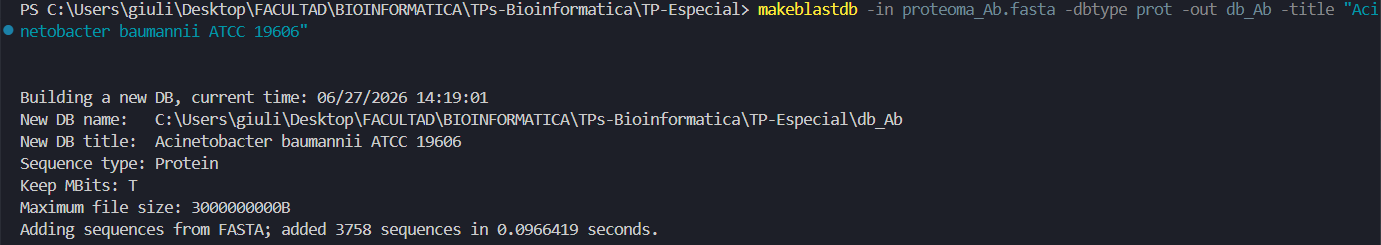

Ahora corremos el BLAST de los 5 genes contra el proteoma de A. baumannii.

*blastp -query query_blancos.fasta -db db_Ab -out resultados_blast.txt -outfmt "6 qseqid sseqid pident length evalue bitscore stitle" -evalue 1e-5 -max_target_seqs 1 -num_threads 4*

### **Paso 9: preparación de secuencias para modelado estructural y análisis en VMD**

Preparamos las secuencias para modelar las estructuras 3D de los 5 genes en Pseudomonas extremaustralis y de sus ortólogos en Acinetobacter baumannii 

### lpxH:

In [3]:
# Archivos
query_file = "query_blancos.fasta"
proteoma_ab = "proteoma_Ab.fasta"

# IDs del BLAST para lpxH
query_id = "lpxH_Pseudomonas_extremaustralis"
ab_id = "WP_000221671.1"

# Extraer lpxH de Pseudomonas
seqs = []

for record in SeqIO.parse(query_file, "fasta"):
    if record.id == query_id:
        record.id = "lpxH_Pseudomonas_extremaustralis"
        record.description = ""
        seqs.append(record)

# Extraer ortólogo de A. baumannii
for record in SeqIO.parse(proteoma_ab, "fasta"):
    if ab_id in record.id or ab_id in record.description:
        record.id = "lpxH_Acinetobacter_baumannii"
        record.description = ""
        seqs.append(record)

SeqIO.write(seqs, "lpxH_proxy_vs_ab.fasta", "fasta")

print("Archivo generado: lpxH_proxy_vs_ab.fasta")
for s in seqs:
    print(s.id, len(s.seq))

Archivo generado: lpxH_proxy_vs_ab.fasta
lpxH_Pseudomonas_extremaustralis 254
lpxH_Acinetobacter_baumannii 239


### aat:

In [1]:
from Bio import SeqIO

# Archivos
query_file = "query_blancos.fasta"
proteoma_ab = "proteoma_Ab.fasta"

# IDs del BLAST para aat
query_id = "aat_Pseudomonas_extremaustralis"
ab_id = "WP_000854789.1"

# Extraer aat de Pseudomonas extremaustralis
seqs = []

for record in SeqIO.parse(query_file, "fasta"):
    if record.id == query_id:
        record.id = "aat_Pseudomonas_extremaustralis"
        record.description = ""
        seqs.append(record)

# Extraer ortólogo de A. baumannii
for record in SeqIO.parse(proteoma_ab, "fasta"):
    if ab_id in record.id or ab_id in record.description:
        record.id = "aat_Acinetobacter_baumannii"
        record.description = ""
        seqs.append(record)

SeqIO.write(seqs, "aat_proxy_vs_ab.fasta", "fasta")

print("Archivo generado: aat_proxy_vs_ab.fasta")
for s in seqs:
    print(s.id, len(s.seq))

Archivo generado: aat_proxy_vs_ab.fasta
aat_Pseudomonas_extremaustralis 226
aat_Acinetobacter_baumannii 243


### rplA

In [2]:
from Bio import SeqIO

# Archivos
query_file = "query_blancos.fasta"
proteoma_ab = "proteoma_Ab.fasta"

# IDs del BLAST para rplA
query_id = "rplA_Pseudomonas_extremaustralis"
ab_id = "WP_001096694.1"

seqs = []

# Extraer rplA de Pseudomonas extremaustralis
for record in SeqIO.parse(query_file, "fasta"):
    if record.id == query_id:
        record.id = "rplA_Pseudomonas_extremaustralis"
        record.description = ""
        seqs.append(record)

# Extraer ortólogo rplA de A. baumannii
for record in SeqIO.parse(proteoma_ab, "fasta"):
    if ab_id in record.id or ab_id in record.description:
        record.id = "rplA_Acinetobacter_baumannii"
        record.description = ""
        seqs.append(record)

SeqIO.write(seqs, "rplA_proxy_vs_ab.fasta", "fasta")

print("Archivo generado: rplA_proxy_vs_ab.fasta")
for s in seqs:
    print(s.id, len(s.seq))

Archivo generado: rplA_proxy_vs_ab.fasta
rplA_Pseudomonas_extremaustralis 231
rplA_Acinetobacter_baumannii 231


### rplJ:

In [2]:
from Bio import SeqIO

query_file = "query_blancos.fasta"
proteoma_ab = "proteoma_Ab.fasta"

query_id = "rplJ_Pseudomonas_extremaustralis"
ab_id = "WP_001196213.1"

seqs = []

for record in SeqIO.parse(query_file, "fasta"):
    if record.id == query_id:
        record.id = "rplJ_Pseudomonas_extremaustralis"
        record.description = ""
        seqs.append(record)

for record in SeqIO.parse(proteoma_ab, "fasta"):
    if ab_id in record.id or ab_id in record.description:
        record.id = "rplJ_Acinetobacter_baumannii"
        record.description = ""
        seqs.append(record)

SeqIO.write(seqs, "rplJ_proxy_vs_ab.fasta", "fasta")

print("Archivo generado: rplJ_proxy_vs_ab.fasta")
for s in seqs:
    print(s.id, len(s.seq))

Archivo generado: rplJ_proxy_vs_ab.fasta
rplJ_Pseudomonas_extremaustralis 166
rplJ_Acinetobacter_baumannii 168


### queF:

In [3]:
from Bio import SeqIO

# Archivos
query_file = "query_blancos.fasta"
proteoma_ab = "proteoma_Ab.fasta"

# IDs para queF
query_id = "queF_Pseudomonas_extremaustralis"
ab_id = "WP_000110165.1"

seqs = []

# Extraer queF de Pseudomonas extremaustralis
for record in SeqIO.parse(query_file, "fasta"):
    if record.id == query_id:
        record.id = "queF_Pseudomonas_extremaustralis"
        record.description = ""
        seqs.append(record)

# Extraer ortólogo queF de Acinetobacter baumannii
for record in SeqIO.parse(proteoma_ab, "fasta"):
    if ab_id in record.id or ab_id in record.description:
        record.id = "queF_Acinetobacter_baumannii"
        record.description = ""
        seqs.append(record)

# Guardar archivo FASTA para AlphaFold
SeqIO.write(seqs, "queF_proxy_vs_ab.fasta", "fasta")

print("Archivo generado: queF_proxy_vs_ab.fasta")
for s in seqs:
    print(s.id, len(s.seq))

Archivo generado: queF_proxy_vs_ab.fasta
queF_Pseudomonas_extremaustralis 276
queF_Acinetobacter_baumannii 270
